In [1]:
import PcmPy as pcm
import os
import numpy as np
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.vis import plot_rdm
from SensoriMotorPrediction.util import lower_noise_ceiling, upper_noise_ceiling
from SensoriMotorPrediction.pcm_models import make_execution_models

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


In [2]:
glm = 16
experiment = 'smp2'
N = 14
H = 'L'
rois = gl.rois['ROI']
vmin, vmax = -1, 1

mask = np.triu(np.ones((8, 8)), 1,).astype(bool)

M = make_execution_models()
G_fin = M[1].G
G_cue = M[2].G
G_sur = M[4].G

D_fin = pcm.G_to_dist(G_fin)
cos_fin = pcm.G_to_cosine(G_fin)
cos_fin_f = cos_fin[mask]

D_cue = pcm.G_to_dist(G_cue)
cos_cue = pcm.G_to_cosine(G_cue)
cos_cue_f = cos_cue[mask]

D_sur = pcm.G_to_dist(G_sur)
cos_sur = pcm.G_to_cosine(G_sur)
cos_sur_f = cos_sur[mask]

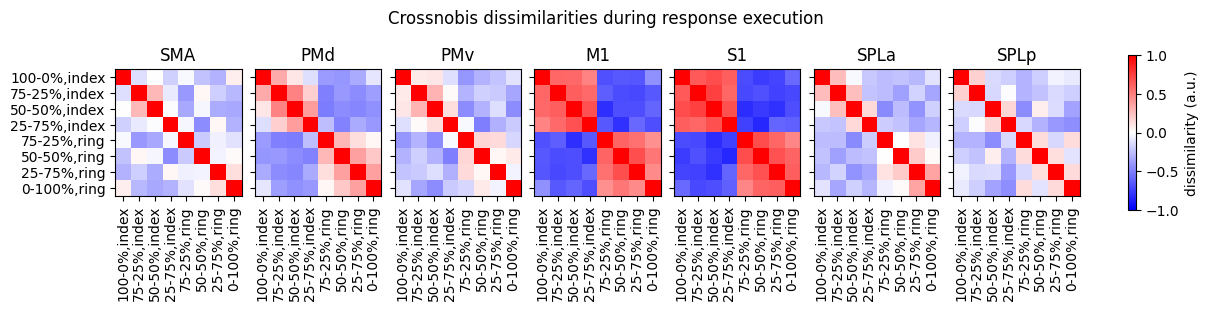

In [3]:
fig, axs = plt.subplots(1, len(rois), figsize=(12, 3),sharex=True, sharey=True, constrained_layout=True)

corr_sur = np.zeros((len(rois), N))
corr_cue = np.zeros_like(corr_sur)
corr_fin = np.zeros_like(corr_sur)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    cos = pcm.G_to_cosine(G)
    cos_f = cos[:, mask]
    corr_fin[r] = np.corrcoef(cos_fin_f, cos_f)[0, 1:]
    corr_cue[r] = np.corrcoef(cos_cue_f, cos_f)[0, 1:]
    corr_sur[r] = np.corrcoef(cos_sur_f, cos_f)[0, 1:]
    plot_rdm(fig, axs, r, cos, gl.conditions[5:], vmin=vmin, vmax=vmax, sqrt=False, source=roi, cmap='bwr', show_t_stat=False)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')
fig.savefig(os.path.join('figures', 'crossnobis.exec.pdf'))
plt.show()

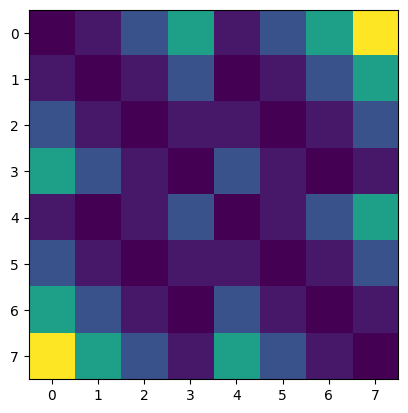

In [8]:
plt.imshow(D_cue)

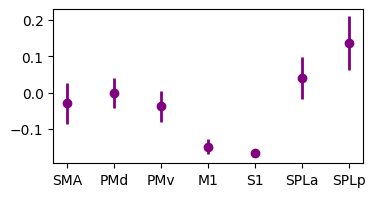

In [12]:
fig, ax = plt.subplots(figsize=(4, 2))

width = 0.3
x = np.arange(len(rois))

rng = np.random.default_rng(0)
jitter = 0.05

# for n in range(N):
#     ax.plot(x - width/2 + rng.uniform(-jitter, jitter, len(rois)), corr_exp[:, n], color='r', alpha=0.3, lw=0, marker='.', ms=3)
#     ax.plot(x + width/2 + rng.uniform(-jitter, jitter, len(rois)), corr_unc[:, n], color='b', alpha=0.3, lw=0, marker='.', ms=3)

#ax.errorbar(x, corr_fin.mean(axis=1), yerr=corr_fin.std(axis=1) / np.sqrt(N), color='gold', label='sensory input', lw=2, ls='none', marker='o')
#ax.errorbar(x, corr_cue.mean(axis=1), yerr=corr_cue.std(axis=1) / np.sqrt(N), color='red', label='expectation', lw=2, ls='none', marker='o')
ax.errorbar(x, corr_sur.mean(axis=1), yerr=corr_sur.std(axis=1) / np.sqrt(N), color='purple', label='surprise', lw=2, ls='none', marker='o')
ax.set_xticks(x)
ax.set_xticklabels(rois)

for r, roi in enumerate(rois):
    ttest_one_exp = ttest_1samp(corr_sur[r], 0, alternative='greater')
    print(f'{roi}, expectation: rho={corr_exp.mean(axis=1)[r]:.03f}, t-test against 0: t={ttest_one_exp.statistic:.03f}, p={ttest_one_exp.pvalue:.03f}; t-test against lower noise ceiling: t={ttest_dep_exp.statistic:.03f}, p={ttest_dep_exp.pvalue:.03f}')
    print(f'{roi}, uncertainty: rho={corr_unc.mean(axis=1)[r]:.03f}, t-test against 0: t={ttest_one_unc.statistic:.03f}, p={ttest_one_unc.pvalue:.03f}; t-test against lower noise ceiling: t={ttest_dep_unc.statistic:.03f}, p={ttest_dep_unc.pvalue:.03f}')
  

plt.show()